# 1. Investigating the Raw KETI Sensor Data
Before analyzing the KETI sensor data, we must inspect the raw combined dataset. Because the 51 rooms use different sensors (Temperature/Humidity/Light/CO2 sampling every 5 seconds, and PIR sampling every 10 seconds), joining them on the exact timestamp creates a huge amount of staggered, misaligned rows. 

We load the raw combined data to observe this "outer join" effect.

In [ ]:
from pathlib import Path
import pandas as pd

raw_dir = Path('../../data/raw/KETI')
combined_path = Path('../../data/interim/combined_keti_sensor_data.csv')
quality_report_path = Path('../../data/interim/keti_1min_quality_report.csv')

if combined_path.exists():
    raw_keti = pd.read_csv(combined_path, dtype={'room': str})
    print(f'Raw combined dataset shape: {raw_keti.shape[0]:,} rows x {raw_keti.shape[1]} columns')
    print('\nMissing Values (NaNs) caused by asynchronous sensor sampling:')
    display(raw_keti.isna().sum())
    display(raw_keti[raw_keti['room'] == '413'].head(10))
else:
    raw_keti = None
    print(f'Combined raw file not found at {combined_path}.')
    print('The fixed resampling pipeline no longer depends on this large exact-second outer-join file.')
    if quality_report_path.exists():
        quality_report = pd.read_csv(quality_report_path, dtype={'room': str})
        display(quality_report.head(10))


Combined raw file not found at ../data/interim/combined_keti_sensor_data.csv.
The fixed resampling pipeline no longer depends on this large exact-second outer-join file.


,room,sensor,raw_rows,valid_rows,invalid_rows,first_timestamp,last_timestamp
0,413,co2,130912,130912,0,2013-08-23 23:05:07,2013-08-31 18:23:29
1,413,humidity,130860,130860,0,2013-08-23 23:05:07,2013-08-31 18:23:29
2,413,light,130860,130860,0,2013-08-23 23:05:07,2013-08-31 18:23:29
3,413,temperature,130860,130860,0,2013-08-23 23:05:07,2013-08-31 18:23:29
4,413,pir,72186,72186,0,2013-08-23 23:05:08,2013-09-01 06:58:54
5,415,co2,132006,132006,0,2013-08-23 16:24:18,2013-09-01 05:17:54
6,415,humidity,130893,130893,0,2013-08-23 23:05:07,2013-08-31 18:23:29
7,415,light,130893,130893,0,2013-08-23 23:05:07,2013-08-31 18:23:29
8,415,temperature,130892,130892,0,2013-08-23 23:05:07,2013-08-31 18:23:29
9,415,pir,76131,76131,0,2013-08-23 23:05:28,2013-09-01 06:58:50


# 2. PIR Mystery
 The Kaggle description says PIR indicates occupancy, but it doesn't specify if it's a binary 0/1 or something else. 
 So we check the range of PIR values

In [2]:
if raw_keti is not None:
    pir_values = raw_keti['pir'].dropna()
else:
    pir_frames = []
    for pir_path in sorted(raw_dir.glob('*/pir.csv')):
        room = pir_path.parent.name
        pir_df = pd.read_csv(pir_path, header=None, names=['timestamp', 'pir'], skipinitialspace=True)
        pir_df['room'] = room
        pir_frames.append(pir_df[['room', 'timestamp', 'pir']])
    raw_pir = pd.concat(pir_frames, ignore_index=True)
    pir_values = raw_pir['pir']

print('PIR Statistics:')
display(pir_values.describe())

print('\nTop 10 most frequent PIR values:')
display(pir_values.value_counts().head(10))


PIR Statistics:


count    3.593953e+06
mean     1.754301e+00
std      1.934540e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.445600e+04
Name: pir, dtype: float64


Top 10 most frequent PIR values:


pir
0.0     3337283
30.0     103452
29.0      25510
28.0      15855
27.0      11627
26.0       9270
25.0       7756
24.0       6743
23.0       6043
22.0       5431
Name: count, dtype: int64

In [3]:
print('Frequency of the highest PIR values:')
display(pir_values.value_counts().sort_index(ascending=False).head(10))


Frequency of the highest PIR values:


pir
34456.0         1
30.0       103452
29.0        25510
28.0        15855
27.0        11627
26.0         9270
25.0         7756
24.0         6743
23.0         6043
22.0         5431
Name: count, dtype: int64

In [4]:
print('Raw Data Ranges:')
if raw_keti is not None:
    display(raw_keti.describe())
else:
    raw_range_rows = []
    for sensor in ['co2', 'humidity', 'light', 'temperature', 'pir']:
        values = []
        for sensor_path in sorted(raw_dir.glob(f'*/{sensor}.csv')):
            sensor_df = pd.read_csv(sensor_path, header=None, names=['timestamp', sensor], skipinitialspace=True)
            values.append(pd.to_numeric(sensor_df[sensor], errors='coerce'))
        sensor_values = pd.concat(values, ignore_index=True)
        raw_range_rows.append({
            'sensor': sensor,
            'count': sensor_values.count(),
            'mean': sensor_values.mean(),
            'std': sensor_values.std(),
            'min': sensor_values.min(),
            'max': sensor_values.max(),
        })
    display(pd.DataFrame(raw_range_rows).set_index('sensor'))

print(f'Max PIR value in raw data: {pir_values.max()}')
occupied_count = (pir_values > 0).sum()
print(f'Total non-zero PIR readings: {occupied_count:,}')


Raw Data Ranges:


,count,mean,std,min,max
sensor,,,,,
co2,6574008,411.006576,103.515413,8.00,1699.00
humidity,6571465,56.747705,4.307900,-500.96,71.91
light,6571463,82.261557,310.154710,0.00,30551.00
temperature,6571505,23.970199,21.191679,-40.10,579.27
pir,3593953,1.754301,19.345402,0.00,34456.00


Max PIR value in raw data: 34456.0
Total non-zero PIR readings: 256,670


# 3 The Solution: Time-Series Resampling
The raw sensor streams are asynchronous, so the trustworthy unit of analysis is a room-level time grid rather than an exact-second outer join.

The fixed resampling script (`scripts/resample_keti_data.py`) now reads each raw room/sensor file directly, resamples each stream into **1-minute intervals**, and then joins the minute-level streams by `room` and `timestamp`.

* **Continuous features** (`co2`, `humidity`, `light`, `temperature`) are aggregated using their minute mean after conservative physical-range filtering.
* **PIR** is binarized per raw observation (`> 0`) and aggregated using minute max. Missing PIR observations remain missing; they are no longer silently converted to `0`.
* **Coverage columns** such as `co2_observations` and `pir_observations` show how many raw readings contributed to each minute.
* Missing values are preserved instead of forward/back-filled so correlation and modeling work can decide explicitly how to handle gaps.


In [ ]:
data_6 = pd.read_csv('../../data/interim/keti_1min_resampled.csv', dtype={'room': str})
data_6['timestamp'] = pd.to_datetime(data_6['timestamp'])

print(f"Resampled Dataset Shape: {data_6.shape[0]:,} rows x {data_6.shape[1]} columns")
print(f"Rooms: {data_6['room'].nunique()}")
print(f"Timestamp range: {data_6['timestamp'].min()} to {data_6['timestamp'].max()}")

print("\nMissing Values after 1-minute resampling (kept intentionally):")
display(data_6.isna().sum())

display(data_6.head())


Resampled Dataset Shape: 604,891 rows x 12 columns
Rooms: 51
Timestamp range: 2013-08-23 15:00:00 to 2013-09-01 06:58:00

Missing Values after 1-minute resampling (kept intentionally):


room                            0
timestamp                       0
co2                         78698
humidity                    56291
light                       56291
temperature                 56289
pir                         16275
co2_observations                0
humidity_observations           0
light_observations              0
temperature_observations        0
pir_observations                0
dtype: int64

,room,timestamp,co2,humidity,light,temperature,pir,co2_observations,humidity_observations,light_observations,temperature_observations,pir_observations
0,413,2013-08-23 23:05:00,494.727273,45.3300,96.555556,23.927778,0.0,11,9,9,9,7
1,413,2013-08-23 23:06:00,496.666667,45.3275,96.833333,23.938333,0.0,12,12,12,12,6
2,413,2013-08-23 23:07:00,498.916667,45.3250,97.333333,23.942500,0.0,12,12,12,12,6
3,413,2013-08-23 23:08:00,504.166667,45.3125,97.083333,23.952500,0.0,12,12,12,12,6
4,413,2013-08-23 23:09:00,499.500000,45.3100,97.416667,23.955833,0.0,12,12,12,12,6


# Closer look at data authenticity
These checks separate three questions that are easy to blur together: pooled building-level correlation, within-room correlation, and missing sensor coverage. If pooled correlations are weak but within-room correlations are meaningful, the extraction is not necessarily broken; room baselines are masking local time-series relationships.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['co2', 'humidity', 'light', 'temperature', 'pir']
coverage_cols = [f'{feature}_observations' for feature in features]

def plot_corr(corr, title, figsize=(7, 5)):
    plt.figure(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.8},
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

display(data_6[coverage_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
co2_observations,604891.0,10.371416,4.073125,0.0,12.0,12.0,12.0,13.0
humidity_observations,604891.0,10.863880,3.494770,0.0,12.0,12.0,12.0,13.0
light_observations,604891.0,10.863873,3.494764,0.0,12.0,12.0,12.0,13.0
temperature_observations,604891.0,10.848188,3.494252,0.0,12.0,12.0,12.0,13.0
pir_observations,604891.0,5.941489,1.343826,0.0,6.0,6.0,6.0,32.0


Complete feature minutes: 511,171 / 604,891


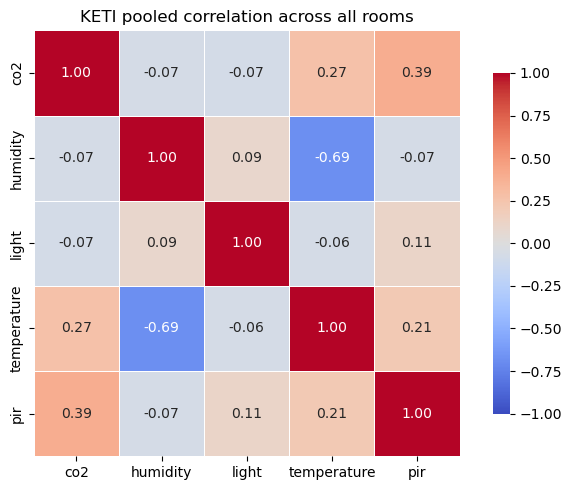

In [7]:
complete_minutes = data_6.dropna(subset=features).copy()
print(f'Complete feature minutes: {len(complete_minutes):,} / {len(data_6):,}')

pooled_corr = complete_minutes[features].corr()
plot_corr(pooled_corr, 'KETI pooled correlation across all rooms')


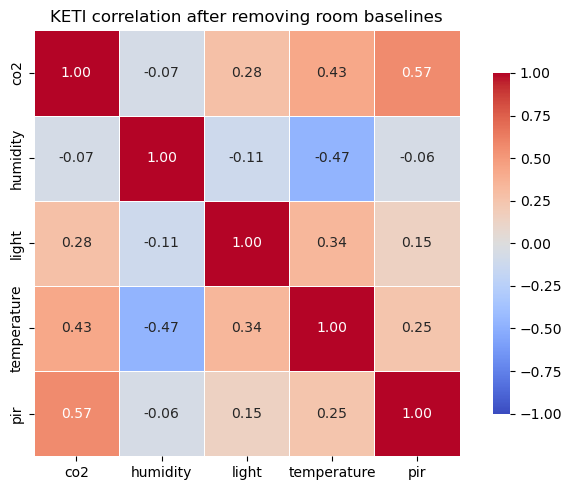

In [8]:
room_demeaned = complete_minutes.copy()
room_demeaned[features] = room_demeaned.groupby('room')[features].transform(lambda col: col - col.mean())

room_demeaned_corr = room_demeaned[features].corr()
plot_corr(room_demeaned_corr, 'KETI correlation after removing room baselines')


,count,median,mean,min,max
pair,,,,,
co2 / pir,48,0.543,0.428,-0.012,0.835
co2 / light,51,0.503,0.469,-0.084,0.861
co2 / temperature,51,0.418,0.395,-0.261,0.815
light / pir,48,0.383,0.386,-0.064,0.926
light / temperature,51,0.375,0.322,-0.216,0.741
temperature / pir,48,0.145,0.186,-0.063,0.578
humidity / pir,48,-0.011,-0.026,-0.383,0.198
co2 / humidity,51,-0.076,-0.048,-0.515,0.555
humidity / light,51,-0.079,-0.072,-0.409,0.580


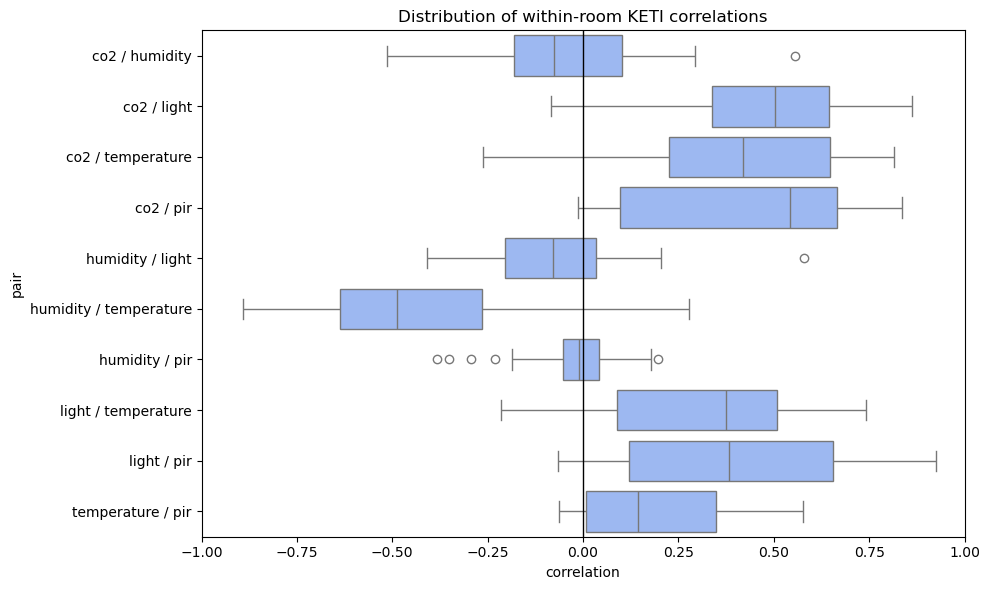

In [9]:
pair_rows = []
for room, room_df in complete_minutes.groupby('room'):
    room_corr = room_df[features].corr()
    for i, left in enumerate(features):
        for right in features[i + 1:]:
            pair_rows.append({
                'room': room,
                'pair': f'{left} / {right}',
                'correlation': room_corr.loc[left, right],
            })

per_room_corr = pd.DataFrame(pair_rows)
per_room_summary = (
    per_room_corr
    .groupby('pair')['correlation']
    .agg(['count', 'median', 'mean', 'min', 'max'])
    .sort_values('median', ascending=False)
)
display(per_room_summary.round(3))

plt.figure(figsize=(10, 6))
sns.boxplot(data=per_room_corr, y='pair', x='correlation', color='#8fb3ff')
plt.axvline(0, color='black', linewidth=1)
plt.title('Distribution of within-room KETI correlations')
plt.xlim(-1, 1)
plt.tight_layout()
plt.show()


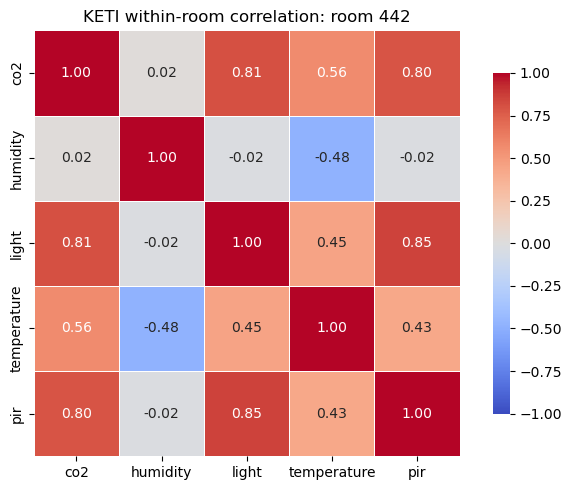

In [10]:
example_room = complete_minutes.groupby('room').size().idxmax()
example_corr = complete_minutes.loc[complete_minutes['room'] == example_room, features].corr()
plot_corr(example_corr, f'KETI within-room correlation: room {example_room}')
